# Urban Water Quality Prediction (Refined & Commented)
This notebook walks through the full pipeline step by step:
1. Load and inspect the data
2. Clean it (fix data types, handle missing values)
3. Engineer the Water Quality Index (WQI)
4. Visualize it
5. Train a Random Forest model to predict WQI

Every cell has comments explaining **what** it does and **why**.

In [1]:
# ---------------------------------------------------------------
# STEP 0: Import the libraries we need
# ---------------------------------------------------------------
import numpy as np                 # numerical operations
import pandas as pd                # loading and manipulating tabular data
import seaborn as sns              # nicer statistical plots
import matplotlib.pyplot as plt    # basic plotting
import warnings
warnings.filterwarnings('ignore')  # hide noisy warning messages


## Step 1: Load the dataset
Change the `file_path` below to wherever your `water_data.csv` lives on your machine.

In [2]:
# ---------------------------------------------------------------
# STEP 1: Load the CSV file
# encoding='ISO-8859-1' is used because this government dataset
# contains some special characters (like the µ in µmhos/cm) that
# the default UTF-8 encoding can't read.
# low_memory=False stops pandas from guessing column dtypes in
# chunks, which avoids "mixed type" warnings on large files.
# ---------------------------------------------------------------
#file_path = 'water_data.csv'   # <-- change this to your actual file path
file_path = r"C:\Users\iammu\Downloads\water_dataX.csv"
data = pd.read_csv(file_path, encoding='ISO-8859-1', low_memory=False)


In [3]:
# ---------------------------------------------------------------
# STEP 2: First look at the data
# ---------------------------------------------------------------
print("Shape (rows, columns):", data.shape)
data.head()


Shape (rows, columns): (1991, 12)


,STATION CODE,LOCATIONS,STATE,Temp,D.O. (mg/l),PH,CONDUCTIVITY (µmhos/cm),B.O.D. (mg/l),NITRATENAN N+ NITRITENANN (mg/l),FECAL COLIFORM (MPN/100ml),TOTAL COLIFORM (MPN/100ml)Mean,year
0,1393,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203,NAN,0.1,11,27,2014
1,1399,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189,2,0.2,4953,8391,2014
2,1475,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179,1.7,0.1,3243,5330,2014
3,3181,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64,3.8,0.5,5382,8443,2014
4,3182,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83,1.9,0.4,3428,5500,2014


In [4]:
data.info()          # column names, non-null counts, dtypes
data.describe()       # basic statistics for numeric columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1991 entries, 0 to 1990
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   STATION CODE                      1991 non-null   object
 1   LOCATIONS                         1991 non-null   object
 2   STATE                             1991 non-null   object
 3   Temp                              1991 non-null   object
 4   D.O. (mg/l)                       1991 non-null   object
 5   PH                                1991 non-null   object
 6   CONDUCTIVITY (µmhos/cm)           1991 non-null   object
 7   B.O.D. (mg/l)                     1991 non-null   object
 8   NITRATENAN N+ NITRITENANN (mg/l)  1991 non-null   object
 9   FECAL COLIFORM (MPN/100ml)        1991 non-null   object
 10  TOTAL COLIFORM (MPN/100ml)Mean    1991 non-null   object
 11  year                              1991 non-null   int64 
dtypes: int64(1), object(

,year
count,1991.000000
mean,2010.038172
std,3.057333
min,2003.000000
25%,2008.000000
50%,2011.000000
75%,2013.000000
max,2014.000000


## Step 3: Check for missing values and wrong data types
The numeric-looking columns are actually stored as `object` (text) type. That happens when a column has even one non-numeric entry mixed in (stray text, blanks, symbols) — pandas then treats the whole column as text.

In [5]:
# Count of missing values per column, BEFORE cleaning
data.isnull().sum()


STATION CODE                        0
LOCATIONS                           0
STATE                               0
Temp                                0
D.O. (mg/l)                         0
PH                                  0
CONDUCTIVITY (µmhos/cm)             0
B.O.D. (mg/l)                       0
NITRATENAN N+ NITRITENANN (mg/l)    0
FECAL COLIFORM (MPN/100ml)          0
TOTAL COLIFORM (MPN/100ml)Mean      0
year                                0
dtype: int64

In [6]:
# Check current data types
data.dtypes


STATION CODE                        object
LOCATIONS                           object
STATE                               object
Temp                                object
D.O. (mg/l)                         object
PH                                  object
CONDUCTIVITY (µmhos/cm)             object
B.O.D. (mg/l)                       object
NITRATENAN N+ NITRITENANN (mg/l)    object
FECAL COLIFORM (MPN/100ml)          object
TOTAL COLIFORM (MPN/100ml)Mean      object
year                                 int64
dtype: object

## Step 4: Convert the numeric-looking columns to actual numbers

**Why `pd.to_numeric(..., errors='coerce')` instead of `.astype('float')`?**

`.astype('float')` converts EVERY value, and crashes with a `ValueError` the moment it hits something it can't parse as a number.

`pd.to_numeric(col, errors='coerce')` does the same conversion, but any value it can't parse becomes `NaN` (missing) instead of crashing the whole script. That's essential here because this is messy real-world data.

In [7]:
# ---------------------------------------------------------------
# STEP 4: List every column that SHOULD be numeric but is
# currently stored as text (object) dtype.
# ---------------------------------------------------------------
numeric_columns = [
    'Temp',
    'D.O. (mg/l)',
    'PH',
    'B.O.D. (mg/l)',
    'CONDUCTIVITY (µmhos/cm)',
    'NITRATENAN N+ NITRITENANN (mg/l)',
    'TOTAL COLIFORM (MPN/100ml)Mean'
]

# Loop through and convert each one. errors='coerce' turns any
# unparseable value into NaN instead of raising an error.
for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Confirm it worked -- these columns should now show float64
data.dtypes


STATION CODE                         object
LOCATIONS                            object
STATE                                object
Temp                                float64
D.O. (mg/l)                         float64
PH                                  float64
CONDUCTIVITY (µmhos/cm)             float64
B.O.D. (mg/l)                       float64
NITRATENAN N+ NITRITENANN (mg/l)    float64
FECAL COLIFORM (MPN/100ml)           object
TOTAL COLIFORM (MPN/100ml)Mean      float64
year                                  int64
dtype: object

In [8]:
# Check missing values again -- you'll now see NaNs that were
# hiding as unparseable text before the conversion above.
data.isnull().sum()


STATION CODE                          0
LOCATIONS                             0
STATE                                 0
Temp                                 92
D.O. (mg/l)                          31
PH                                    8
CONDUCTIVITY (µmhos/cm)              25
B.O.D. (mg/l)                        43
NITRATENAN N+ NITRITENANN (mg/l)    225
FECAL COLIFORM (MPN/100ml)            0
TOTAL COLIFORM (MPN/100ml)Mean      132
year                                  0
dtype: int64

## Step 5: Fill in the missing values
We fill each numeric column's missing values with that column's own **mean**. This is a simple, common strategy that keeps the overall distribution roughly intact.

In [9]:
# ---------------------------------------------------------------
# STEP 5: Fill missing values with the column mean
# ---------------------------------------------------------------
for col in numeric_columns:
    data[col].fillna(data[col].mean(), inplace=True)

# Double-check: this should now print all zeros
data.isnull().sum()


STATION CODE                        0
LOCATIONS                           0
STATE                               0
Temp                                0
D.O. (mg/l)                         0
PH                                  0
CONDUCTIVITY (µmhos/cm)             0
B.O.D. (mg/l)                       0
NITRATENAN N+ NITRITENANN (mg/l)    0
FECAL COLIFORM (MPN/100ml)          0
TOTAL COLIFORM (MPN/100ml)Mean      0
year                                0
dtype: int64

## Step 6: Drop redundant columns and rename for simplicity
`FECAL COLIFORM` is dropped because we already have `TOTAL COLIFORM`, which covers it. Long column names are renamed to short, easy-to-type ones.

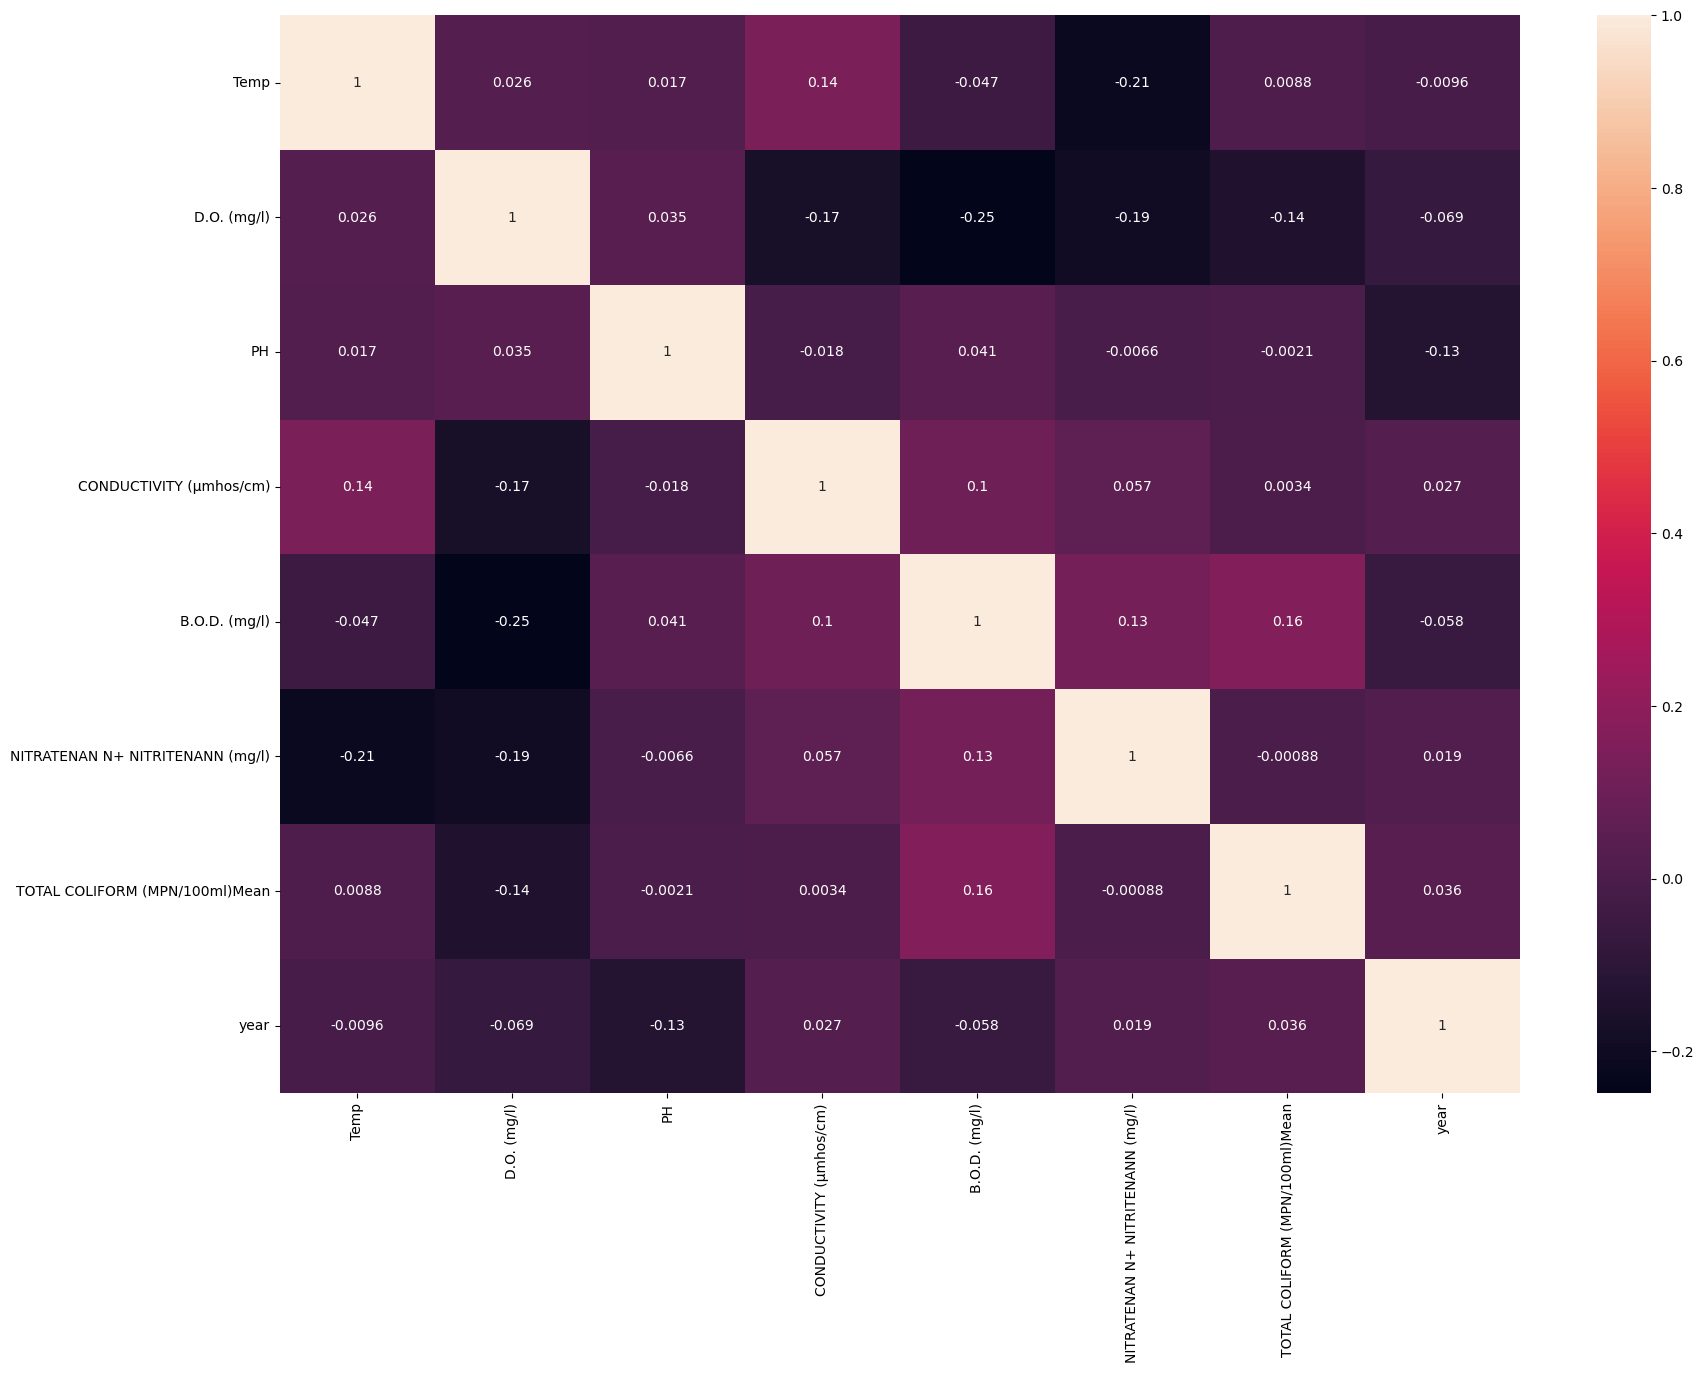

In [10]:
plt.subplots(figsize=(20, 14))
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True)
plt.show()


In [11]:
# Drop the column we don't need
data.drop(['FECAL COLIFORM (MPN/100ml)'], axis=1, inplace=True)

# Rename long column names to short, simple ones
data = data.rename(columns={
    'D.O. (mg/l)': 'do',
    'CONDUCTIVITY (µmhos/cm)': 'co',
    'B.O.D. (mg/l)': 'bod',
    'NITRATENAN N+ NITRITENANN (mg/l)': 'na',
    'TOTAL COLIFORM (MPN/100ml)Mean': 'tc',
    'STATION CODE': 'station',
    'LOCATIONS': 'location',
    'STATE': 'state',
    'PH': 'ph',
})

data.head()


,station,location,state,Temp,do,ph,co,bod,na,tc,year
0,1393,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203.0,6.940049,0.1,27.0,2014
1,1399,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189.0,2.000000,0.2,8391.0,2014
2,1475,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179.0,1.700000,0.1,5330.0,2014
3,3181,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64.0,3.800000,0.5,8443.0,2014
4,3182,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83.0,1.900000,0.4,5500.0,2014


## Step 7: Correlation heatmap
This shows how strongly each numeric column relates to the others -- values close to 1 or -1 mean a strong relationship, values close to 0 mean almost none.

## Step 8: Build the Water Quality Index (WQI)

This is the core science of the notebook. Each raw measurement (pH, dissolved oxygen, etc.) gets converted into a **0-100 quality sub-index**, based on standard water quality guidelines. A value near the ideal range scores close to 100 (great); a value far outside the safe range scores 0 (poor).

All six sub-indices are then combined with fixed weights into one overall WQI score.

In [12]:
# ---------------------------------------------------------------
# pH sub-index
# Ideal range for water is roughly 7.0 - 8.5 (near neutral).
# The further pH drifts from that range in EITHER direction
# (too acidic or too alkaline), the lower the score.
# ---------------------------------------------------------------
data['npH'] = data['ph'].apply(
    lambda x: 100 if 7.0 <= x <= 8.5 else                        # ideal range        -> best score
               80  if (8.5 <= x <= 8.6) or (6.8 <= x <= 6.9) else # slightly off       -> good score
               60  if (8.6 <= x <= 8.8) or (6.7 <= x <= 6.8) else # moderately off     -> fair score
               40  if (8.8 <= x <= 9.0) or (6.5 <= x <= 6.7) else # badly off          -> poor score
               0                                                  # outside 6.5 - 9.0  -> worst score
)


In [13]:
# ---------------------------------------------------------------
# Dissolved Oxygen (DO) sub-index
# Higher dissolved oxygen is BETTER for water quality (aquatic
# life needs oxygen), so the score decreases as DO drops lower.
# ---------------------------------------------------------------
data['ndo'] = data['do'].apply(
    lambda x: 100 if x >= 6 else                    # plenty of oxygen      -> best score
               80  if 5.1 <= x <= 6 else             # good                  -> good score
               60  if 4.1 <= x <= 5 else             # acceptable            -> fair score
               40  if 3   <= x <= 4 else             # low oxygen            -> poor score
               0                                     # very low oxygen       -> worst score
)


In [14]:
# ---------------------------------------------------------------
# Total Coliform sub-index
# Coliform bacteria indicate contamination (often from sewage).
# LOWER coliform counts are BETTER, so the score decreases sharply
# as the bacteria count rises.
# ---------------------------------------------------------------
data['nco'] = data['tc'].apply(
    lambda x: 100 if 0     <= x <= 5     else        # very clean            -> best score
               80  if 5    <= x <= 50    else         # mostly clean          -> good score
               60  if 50   <= x <= 500   else         # some contamination    -> fair score
               40  if 500  <= x <= 10000 else         # heavily contaminated  -> poor score
               0                                      # extremely dirty       -> worst score
)


In [15]:
# ---------------------------------------------------------------
# Biochemical Oxygen Demand (BOD) sub-index
# BOD measures how much oxygen bacteria consume while breaking
# down organic waste in the water. LOWER BOD is BETTER (it means
# less organic pollution).
# ---------------------------------------------------------------
data['nbdo'] = data['bod'].apply(
    lambda x: 100 if 0   <= x <= 3   else            # very little pollution -> best score
               80  if 3  <= x <= 6   else              # low pollution         -> good score
               60  if 6  <= x <= 80  else              # moderate pollution    -> fair score
               40  if 80 <= x <= 125 else              # heavy pollution       -> poor score
               0                                       # extreme pollution     -> worst score
)


In [16]:
# ---------------------------------------------------------------
# Electrical Conductivity sub-index
# Conductivity reflects the amount of dissolved salts/minerals in
# the water. LOWER conductivity is generally BETTER for drinking
# and ecological use.
# ---------------------------------------------------------------
data['nec'] = data['co'].apply(
    lambda x: 100 if 0   <= x <= 75  else            # low dissolved solids  -> best score
               80  if 75  <= x <= 150 else             # slightly higher       -> good score
               60  if 150 <= x <= 225 else             # moderate              -> fair score
               40  if 225 <= x <= 300 else             # high                  -> poor score
               0                                       # very high             -> worst score
)


In [17]:
# ---------------------------------------------------------------
# Nitrate sub-index
# High nitrate levels usually point to fertilizer or sewage
# runoff. LOWER nitrate is BETTER.
# ---------------------------------------------------------------
data['nna'] = data['na'].apply(
    lambda x: 100 if 0   <= x <= 20  else            # very low nitrate      -> best score
               80  if 20  <= x <= 50  else             # low                   -> good score
               60  if 50  <= x <= 100 else             # moderate              -> fair score
               40  if 100 <= x <= 200 else             # high                  -> poor score
               0                                       # very high             -> worst score
)


### Combine the sub-indices into one overall WQI

Each sub-index is multiplied by a fixed **weight** (how important that parameter is to overall water quality), and the weighted scores are added up. The weights below add up to 1.0 (0.165 + 0.281 + 0.234 + 0.009 + 0.028 + 0.281 = 0.998, rounded).

In [18]:
# ---------------------------------------------------------------
# Apply weights to each sub-index, then sum them into one score:
# the final Water Quality Index (WQI). Higher WQI = better water.
# ---------------------------------------------------------------
data['wph']  = data['npH'] * 0.165   # pH weight
data['wdo']  = data['ndo'] * 0.281   # dissolved oxygen weight
data['wbdo'] = data['nbdo'] * 0.234  # BOD weight
data['wec']  = data['nec'] * 0.009   # conductivity weight
data['wna']  = data['nna'] * 0.028   # nitrate weight
data['wco']  = data['nco'] * 0.281   # coliform weight

# Add all the weighted scores together for the final WQI
data['wqi'] = (data['wph'] + data['wdo'] + data['wbdo']
               + data['wec'] + data['wna'] + data['wco'])

data.head()


,station,location,state,Temp,do,ph,co,bod,na,tc,...,nbdo,nec,nna,wph,wdo,wbdo,wec,wna,wco,wqi
0,1393,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203.0,6.940049,0.1,27.0,...,60,60,100,16.5,28.10,14.04,0.54,2.8,22.48,84.46
1,1399,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189.0,2.000000,0.2,8391.0,...,100,60,100,16.5,22.48,23.40,0.54,2.8,11.24,76.96
2,1475,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179.0,1.700000,0.1,5330.0,...,100,60,100,13.2,28.10,23.40,0.54,2.8,11.24,79.28
3,3181,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64.0,3.800000,0.5,8443.0,...,80,100,100,13.2,22.48,18.72,0.90,2.8,11.24,69.34
4,3182,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83.0,1.900000,0.4,5500.0,...,100,80,100,16.5,22.48,23.40,0.72,2.8,11.24,77.14


## Step 9: Look at WQI trends over time

In [19]:
# Average WQI per year
average = data.groupby('year')['wqi'].mean()
yearly_wqi = average.reset_index(level=0, inplace=False)
yearly_wqi


,year,wqi
0,2003,66.239545
1,2004,61.290000
2,2005,73.762689
3,2006,72.909714
4,2007,74.233000
5,2008,73.506289
6,2009,74.456685
7,2010,75.454787
8,2011,76.666580
9,2012,79.496712


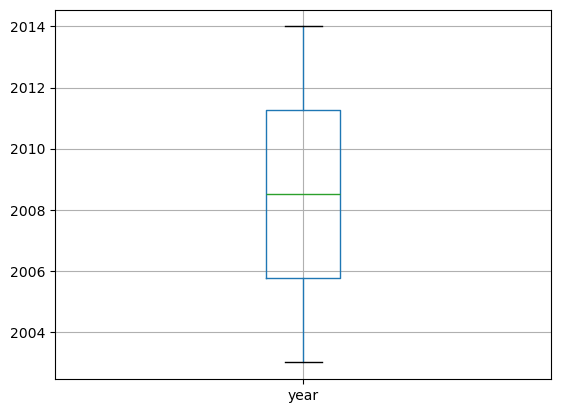

In [20]:
# Boxplot of the 'year' column (sanity check on the year values)
yearly_wqi.boxplot(column='year')
plt.show()


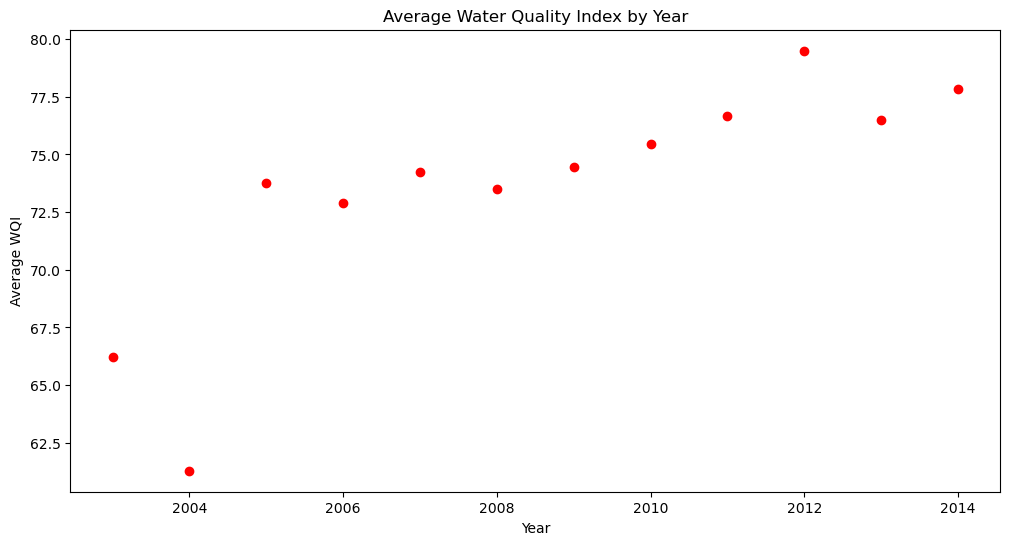

In [21]:
# Scatter plot: year vs average WQI
plt.rcParams['figure.figsize'] = (12.0, 6.0)
plt.scatter(yearly_wqi['year'], yearly_wqi['wqi'], color='red')
plt.xlabel('Year')
plt.ylabel('Average WQI')
plt.title('Average Water Quality Index by Year')
plt.show()


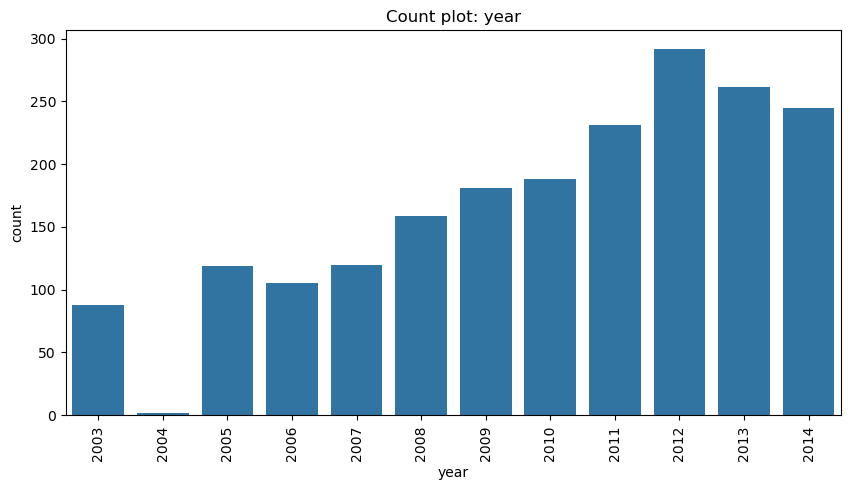

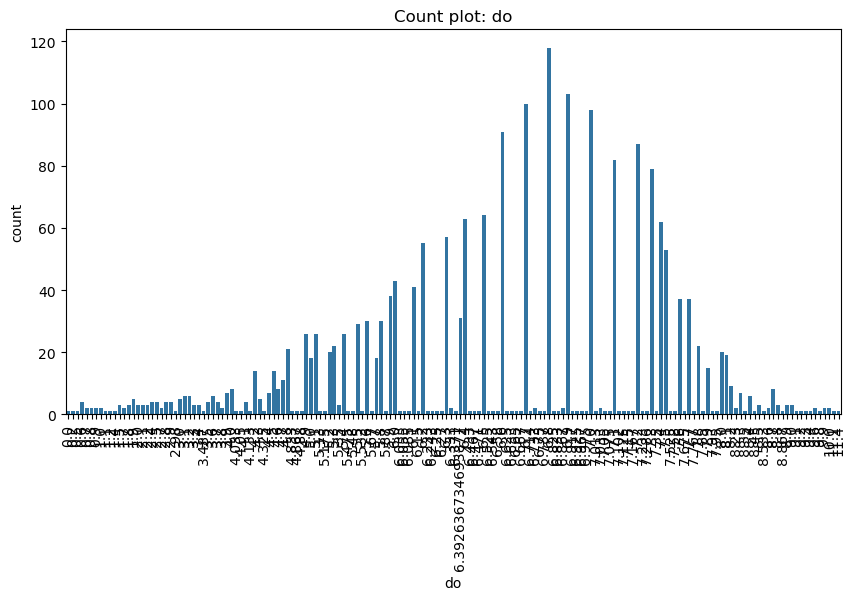

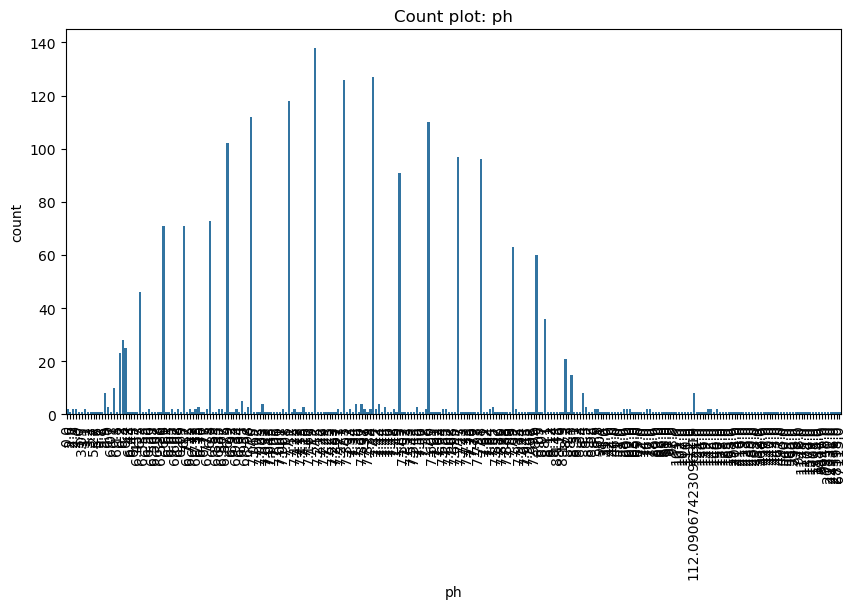

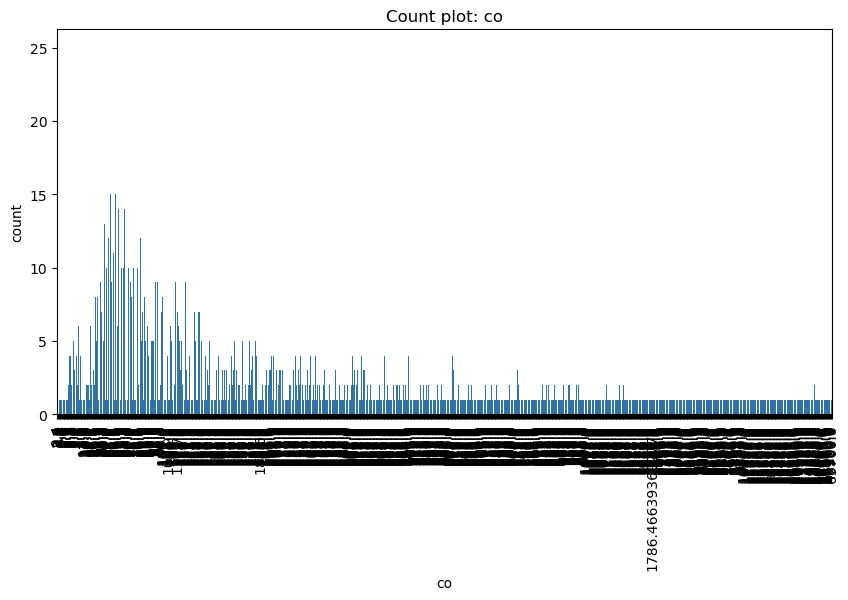

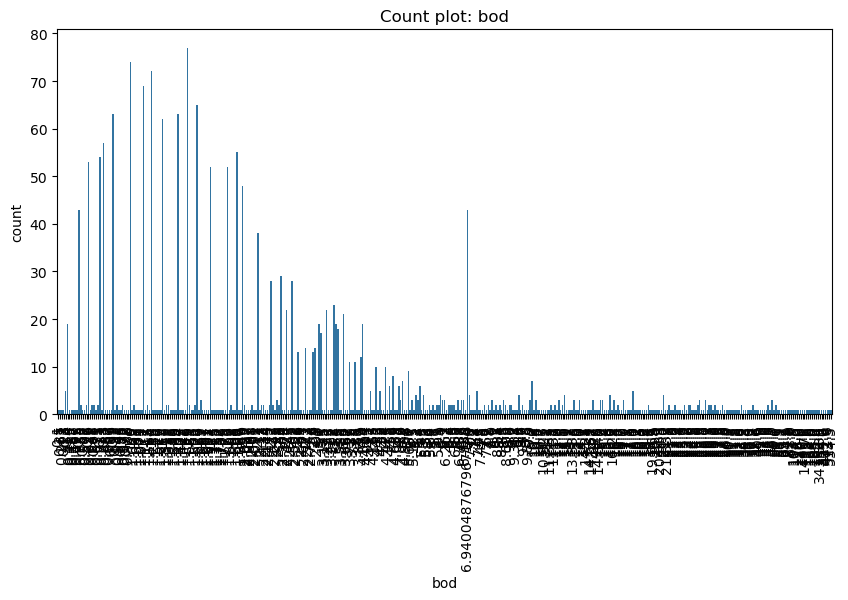

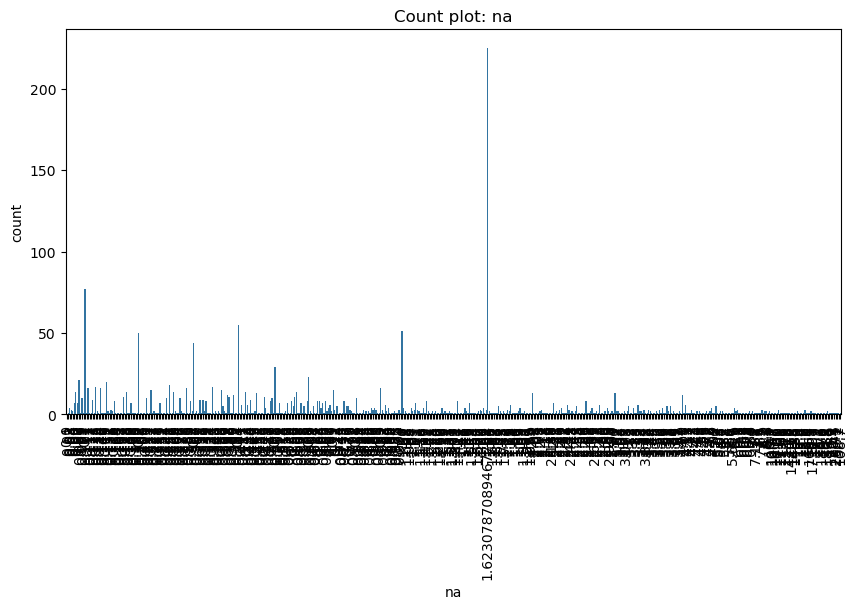

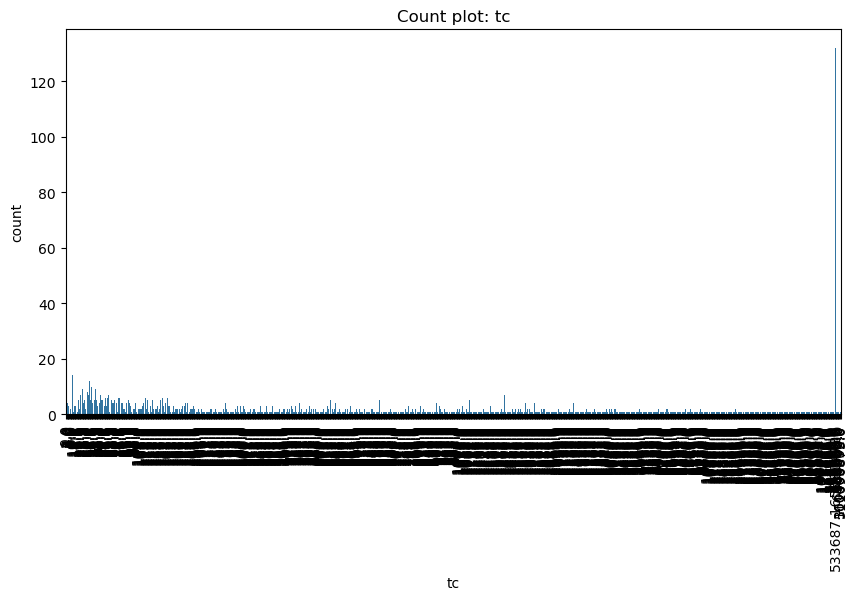

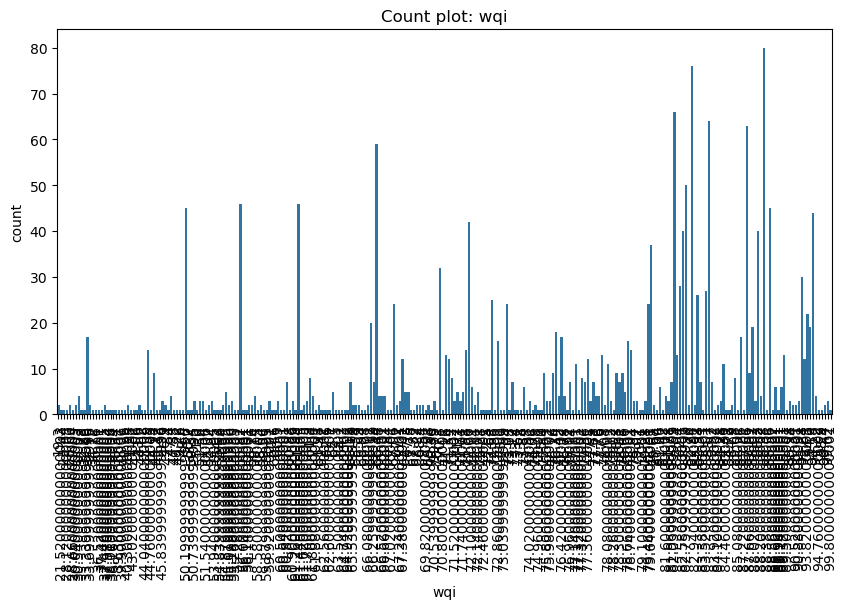

In [22]:
# Distribution of each raw/engineered column
plt.rcParams['figure.figsize'] = (10.0, 5.0)
for col in ['year', 'do', 'ph', 'co', 'bod', 'na', 'tc', 'wqi']:
    plt.figure()
    sns.countplot(x=data[col])
    plt.title(f'Count plot: {col}')
    plt.xticks(rotation=90)
    plt.show()


## Step 10: Prepare the data for modeling

Before training a model, we drop columns that were only needed to *calculate* WQI (the sub-indices and weighted scores) plus non-numeric/identifier columns (`station`, `location`, `state`) and `Temp`, which isn't used as a model input here.

In [23]:
# ---------------------------------------------------------------
# STEP 10: Remove columns that were just intermediate calculations
# or identifiers, keeping only what the model actually needs
# ---------------------------------------------------------------
data.drop([
    'Temp', 'station', 'location', 'state',
    'nbdo', 'nec', 'nna', 'wph', 'wdo', 'wbdo', 'wec', 'wna', 'wco',
    'npH', 'ndo', 'nco'
], axis=1, inplace=True)

data.head()


,do,ph,co,bod,na,tc,year,wqi
0,6.7,7.5,203.0,6.940049,0.1,27.0,2014,84.46
1,5.7,7.2,189.0,2.000000,0.2,8391.0,2014,76.96
2,6.3,6.9,179.0,1.700000,0.1,5330.0,2014,79.28
3,5.8,6.9,64.0,3.800000,0.5,8443.0,2014,69.34
4,5.8,7.3,83.0,1.900000,0.4,5500.0,2014,77.14


## Step 11: Split into features (X) and target (y)
`X` = the input measurements the model learns from. `y` = the WQI score we want it to predict.

In [24]:
# The first 7 columns are the input features (X);
# the remaining column(s) are the target we're predicting (y = wqi)
X = data.iloc[:, 0:7].values
y = data.iloc[:, 7:].values

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (1991, 7)
y shape: (1991, 1)


## Step 12: Feature scaling

The input features are on very different scales (e.g. pH is roughly 0-14, while coliform counts can be in the thousands). `StandardScaler` rescales every feature to have mean 0 and standard deviation 1, so no single feature dominates just because of its raw magnitude.

*Note: Random Forest doesn't strictly require scaling (it's not distance-based like KNN or SVM), but it doesn't hurt and keeps the pipeline reusable for other models.*

In [25]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X = sc.fit_transform(X)
X


array([[ 2.32466585e-01, -5.57912384e-02, -2.87072862e-01, ...,
        -3.95467938e-01, -3.88098511e-02,  1.29617001e+00],
       [-5.23858621e-01, -5.59512658e-02, -2.89610977e-01, ...,
        -3.69502901e-01, -3.82015883e-02,  1.29617001e+00],
       [-7.00634974e-02, -5.61112931e-02, -2.91423917e-01, ...,
        -3.95467938e-01, -3.84241962e-02,  1.29617001e+00],
       ...,
       [ 9.13159270e-01, -7.51631224e-03, -3.22751510e-01, ...,
         0.00000000e+00, -3.87703620e-02, -2.30264077e+00],
       [ 9.88791790e-01, -1.12502844e-02, -3.22697122e-01, ...,
         0.00000000e+00, -3.87709438e-02, -2.30264077e+00],
       [ 9.13159270e-01, -1.11521706e-03, -3.22842157e-01, ...,
         0.00000000e+00, -3.87721073e-02, -2.30264077e+00]])

## Step 13: Split into training and testing sets
80% of the data trains the model, 20% is held back to test how well it generalizes to data it hasn't seen.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)


X_train: (1592, 7)
X_test : (399, 7)
y_train: (1592, 1)
y_test : (399, 1)


## Step 14: Train a Random Forest Regressor

A Random Forest builds many individual decision trees on random subsets of the training data, then averages their predictions. This averaging reduces overfitting compared to a single decision tree.

`n_estimators=10` means it builds 10 trees in the forest.

In [27]:
from sklearn.ensemble import RandomForestRegressor

reg_rf = RandomForestRegressor(n_estimators=10, random_state=0)
reg_rf.fit(X_train, y_train)

y_pred = reg_rf.predict(X_test)
y_pred


array([29.41 , 75.02 , 93.82 , 88.2  , 67.38 , 93.82 , 70.8  , 82.742,
       28.192, 88.02 , 88.2  , 82.94 , 71.88 , 79.64 , 82.94 , 82.608,
       31.074, 69.29 , 70.8  , 73.93 , 77.612, 62.104, 82.04 , 82.58 ,
       85.26 , 33.06 , 83.664, 60.822, 72.464, 88.2  , 66.174, 74.834,
       88.38 , 51.324, 85.242, 72.06 , 87.66 , 87.66 , 72.86 , 83.87 ,
       82.04 , 80.826, 72.06 , 45.676, 88.56 , 71.376, 67.38 , 91.428,
       66.44 , 37.556, 67.06 , 89.386, 55.82 , 82.94 , 76.42 , 85.614,
       82.04 , 71.278, 78.66 , 70.8  , 83.52 , 60.648, 88.56 , 45.466,
       55.82 , 87.732, 79.64 , 70.904, 66.44 , 82.98 , 93.28 , 93.64 ,
       83.52 , 87.66 , 72.86 , 88.506, 82.94 , 86.684, 82.58 , 82.76 ,
       83.7  , 76.174, 77.868, 84.396, 88.488, 65.32 , 61.238, 83.7  ,
       94.18 , 69.492, 76.214, 78.718, 66.44 , 83.794, 55.82 , 45.142,
       82.76 , 45.142, 79.46 , 82.98 , 84.608, 77.14 , 66.546, 73.04 ,
       82.94 , 42.61 , 82.04 , 61.44 , 87.66 , 79.64 , 94.18 , 82.94 ,
      

## Step 15: Score the model

In [28]:
print('Training R² score:', reg_rf.score(X_train, y_train))
print('Testing R² score :', reg_rf.score(X_test, y_test))


Training R² score: 0.9949757710181609
Testing R² score : 0.9698515800253787


In [29]:
# Quick eyeball comparison of a few actual vs predicted values
print('Actual   :', y_test[10:15].ravel())
print('Predicted:', y_pred[10:15])


Actual   : [88.2  82.94 71.88 79.64 82.94]
Predicted: [88.2  82.94 71.88 79.64 82.94]


## Step 16: Evaluate the model with error metrics

- **MAE** (Mean Absolute Error): average size of the errors, in the same units as WQI.
- **MSE** (Mean Squared Error): like MAE but squares errors first, so big mistakes are penalized more.
- **RMSE** (Root Mean Squared Error): square root of MSE, brought back into the same units as WQI so it's easy to interpret.
- **R²**: how much of the variation in WQI the model explains (1.0 = perfect, 0 = no better than guessing the average).

In [30]:
from sklearn import metrics

print('MAE :', metrics.mean_absolute_error(y_test, y_pred))
print('MSE :', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R²  :', metrics.r2_score(y_test, y_pred))


MAE : 0.9361704260651688
MSE : 5.5308069774436115
RMSE: 2.3517667778594906
R²  : 0.9698515800253787


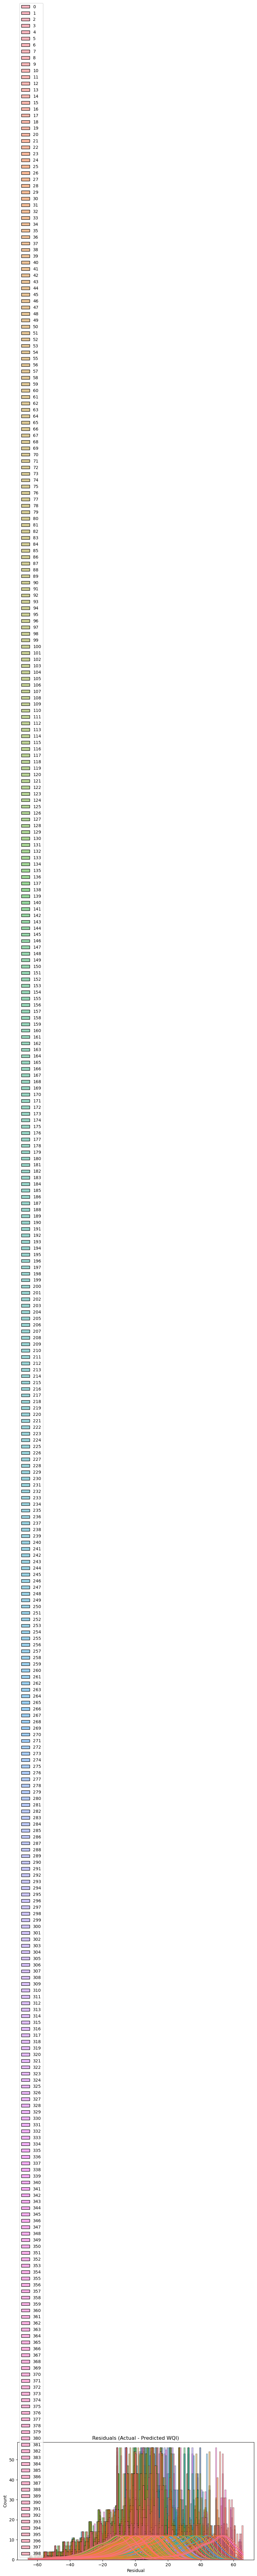

In [31]:
# Plot the distribution of residuals (actual - predicted).
# A distribution centered near 0 with a roughly bell-shaped curve
# suggests the model's errors are small and unbiased.
sns.histplot(y_test - y_pred, kde=True)
plt.title('Residuals (Actual - Predicted WQI)')
plt.xlabel('Residual')
plt.show()


---
**That's the full pipeline through model evaluation.** Saving the trained model with `pickle` (for later reuse) is intentionally left out here.